# 07 — Window Features: Rolling, Expanding & Exponential Smoothing

**Companion notebook to Article 7 of the *Time Series Feature Engineering* series.**

📖 Read the article: [Medium](https://medium.com/@asidd24/window-features-rolling-expanding-exponential-smoothing-b8470fd0bbbf?postPublishedType=initial) · [LinkedIn Newsletter](https://www.linkedin.com/newsletters/time-series-engineered-7485187061080137728/)

---

> *"A lag feature answers 'what happened at time t-7?' A window feature answers 'what did the last 7 days look like as a whole?' The distinction seems small until you see what each contributes to a tree-based model — where window features earn their place capturing something lag features fundamentally cannot: volatility and shape."*

While lag features encode sequential memory and cycle phases, window features synthesize **aggregate behavior over temporal horizons**. In this notebook, we cover:

1. **The Core Distinction**: Lag features (point observations) vs. Window features (aggregate summaries).
2. **Rolling Statistics — The Workhorse**: Shifting to eliminate leakage, choosing seasonal window sizes, and capturing short vs. long trends.
3. **Beyond the Mean**: Why rolling standard deviation is often a top-3 feature in demand forecasting; capturing range with rolling min/max.
4. **Expanding Windows**: The long-run reference baseline, the `min_periods` safeguard, and when expanding windows fail (regime shifts).
5. **Exponentially-Weighted Moving Averages (EWM)**: Decaying memory without arbitrary boundaries, tuning `span`, and why `adjust=False` matters.
6. **Empirical Tree Model Importance**: What LightGBM actually values when given lags, rolling, expanding, and EWM features on a regime-shifting series.
7. **Leakage Traps & Multi-Step Horizons**: Shifting by forecast horizon $H$ with `min_horizon`.
8. **Minimal Defensible Feature Set & Walk-Forward Benchmark**: Validating the incremental lift of window features over pure lag models.


## 1. Setup & Environment

In [1]:
import sys
sys.path.append('..')  # Allow importing from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reusable utilities from src/
from src.data import generate_daily_sales
from src.features import (
    add_lag_features,
    add_rolling_features,
    add_expanding_features,
    add_ewm_features,
    build_forecasting_feature_matrix,
)
from src.metrics import wmape, vandeput_score

# Visual styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4.5)
plt.rcParams['font.size'] = 10
np.random.seed(42)

## 2. Generating Synthetic Retail Series with Volatility Regime Shift

To rigorously test window features, we simulate 730 days (2 years) of daily sales data that exhibits:
- A linear upward trend.
- Strong 7-day weekly seasonality (weekend peaks).
- A **structural volatility regime shift** at midpoint ($t = 365$), where the noise variance increases threefold.

This mimics real-world conditions like entering an inflationary period, rapid catalog expansion, or increased promotional frequency.

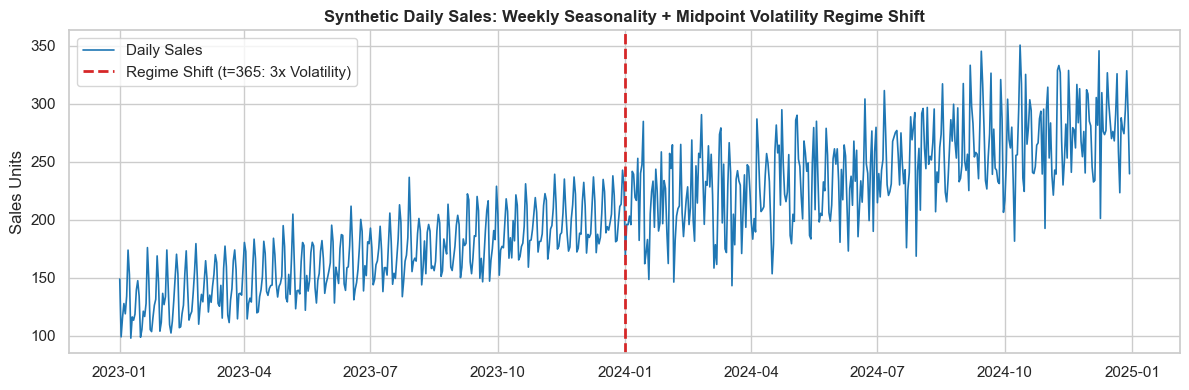

In [2]:
dates = pd.date_range('2023-01-01', periods=730, freq='D')
n = len(dates)

# Base linear trend + weekly seasonal cycle
trend = np.linspace(100, 260, n)
weekly_pattern = np.array([0, 10, 15, 20, 35, 60, 45])  # Mon..Sun
seasonality = weekly_pattern[dates.dayofweek.values]

# Structural Volatility Regime Shift at midpoint
noise = np.zeros(n)
noise[:365] = np.random.normal(0, 8, size=365)     # Regime 1: Calm (low variance)
noise[365:] = np.random.normal(0, 26, size=n - 365) # Regime 2: Volatile (high variance)

sales = pd.Series(trend + seasonality + noise, index=dates, name='sales')

# Visualize the raw series with regime change indicator
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sales.index, sales.values, color='#1f77b4', lw=1.2, label='Daily Sales')
ax.axvline(dates[365], color='#d62728', ls='--', lw=2, label='Regime Shift (t=365: 3x Volatility)')
ax.set_title('Synthetic Daily Sales: Weekly Seasonality + Midpoint Volatility Regime Shift', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales Units')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 3. Lags vs. Windows: Point Observation vs. Aggregate Summary

A lag feature is a **single historical point** ($y_{t-k}$). If that point happens to be an outlier or a temporary holiday dip, the model receives only that solitary reading.

In contrast, a window feature is an **aggregate statistic** computed over an interval $[t-w, t-1]$. It encodes three fundamental dimensions that point lags cannot:
1. **Local level**: The smoothed baseline level of the series.
2. **Local volatility**: The magnitude of recent oscillation / noise around that level.
3. **Local shape & extremes**: The recent peak, trough, and asymmetry.

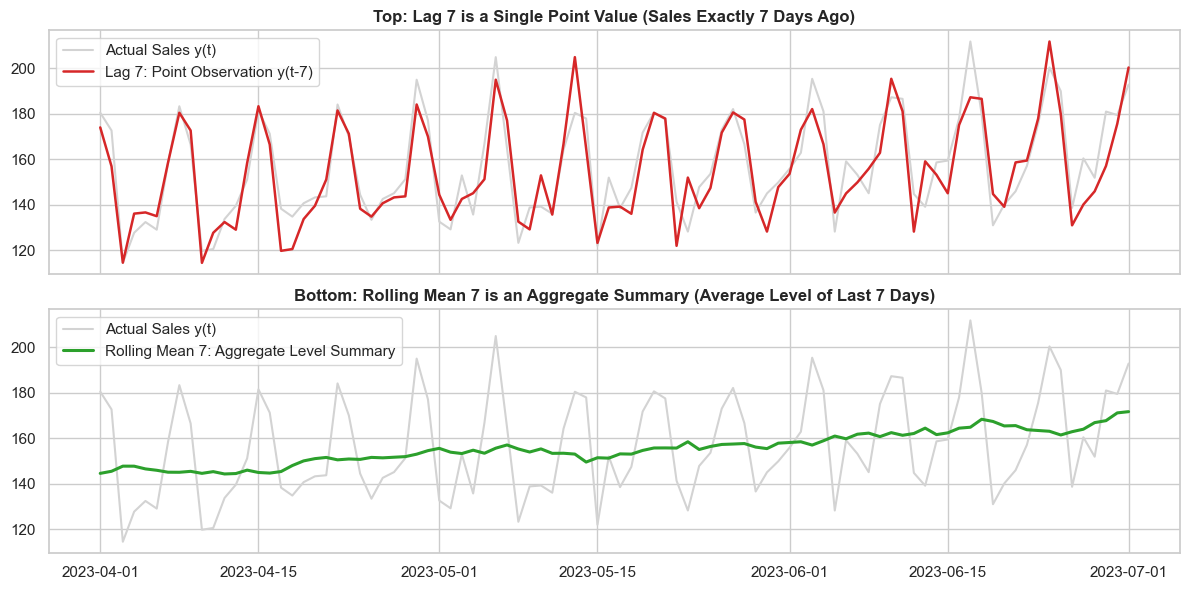

In [3]:
# Figure 1 from the article: Lag 7 vs. Rolling Mean 7
lag_7 = sales.shift(7)
roll_mean_7 = sales.shift(1).rolling(7).mean()

zoom_start, zoom_end = '2023-04-01', '2023-07-01'
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: Lag 7 (Single point observation)
axes[0].plot(sales.loc[zoom_start:zoom_end].index, sales.loc[zoom_start:zoom_end].values, 
             color='lightgray', lw=1.5, label='Actual Sales y(t)')
axes[0].plot(lag_7.loc[zoom_start:zoom_end].index, lag_7.loc[zoom_start:zoom_end].values, 
             color='#d62728', lw=1.8, label='Lag 7: Point Observation y(t-7)')
axes[0].set_title('Top: Lag 7 is a Single Point Value (Sales Exactly 7 Days Ago)', fontweight='bold')
axes[0].legend(loc='upper left', frameon=True)

# Bottom: Rolling Mean 7 (Aggregate summary)
axes[1].plot(sales.loc[zoom_start:zoom_end].index, sales.loc[zoom_start:zoom_end].values, 
             color='lightgray', lw=1.5, label='Actual Sales y(t)')
axes[1].plot(roll_mean_7.loc[zoom_start:zoom_end].index, roll_mean_7.loc[zoom_start:zoom_end].values, 
             color='#2ca02c', lw=2.2, label='Rolling Mean 7: Aggregate Level Summary')
axes[1].set_title('Bottom: Rolling Mean 7 is an Aggregate Summary (Average Level of Last 7 Days)', fontweight='bold')
axes[1].legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## 4. Rolling Statistics — The Workhorse

### The Leakage Golden Rule
The single most common bug in time series feature engineering is calling `.rolling(w).mean()` directly on the unshifted series:

```python
# ❌ LEAKAGE: Window at time t includes target y(t) itself!
df['rolling_mean_7'] = series.rolling(7).mean()

# ✅ LEAKAGE-SAFE: Shift by 1 first
df['rolling_mean_7'] = series.shift(1).rolling(7).mean()
```

### Choosing Window Sizes
A practical rule of thumb for tabular forecasting:
1. **Seasonal Period Window**: Match your primary seasonality (e.g., $w = 7$ for daily data, $w = 12$ for monthly).
2. **Seasonal Multiple**: One multi-cycle window (e.g., $w = 14$ or $w = 28$).
3. **Long-Horizon Trend Window**: A quarterly window (e.g., $w = 90$ days) for macro-level trend smoothing.

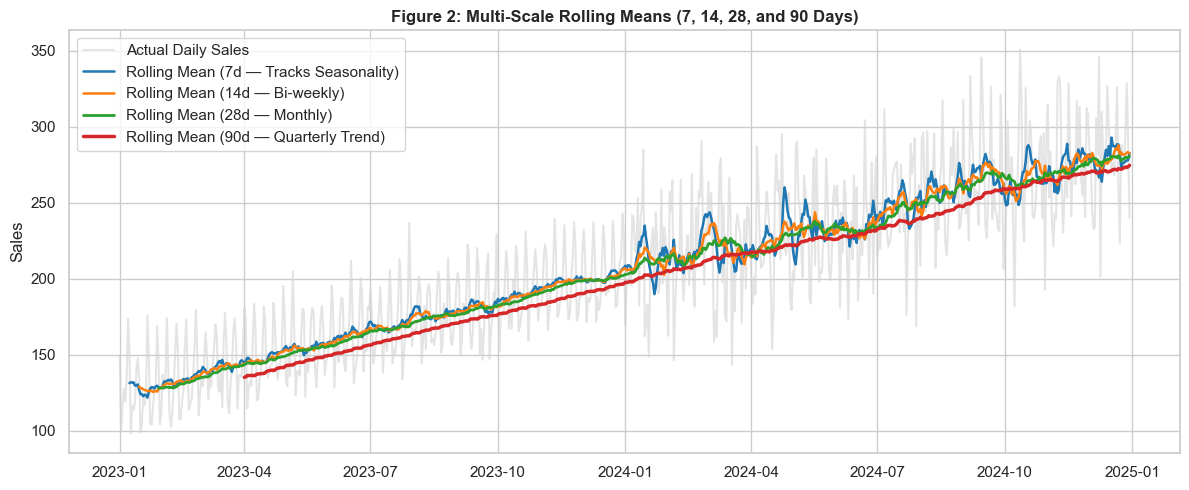

In [4]:
# Figure 2: Rolling means at 7, 14, 28, and 90 days
s = sales.shift(1)  # Shift once, use everywhere safely

roll_7 = s.rolling(7).mean()
roll_14 = s.rolling(14).mean()
roll_28 = s.rolling(28).mean()
roll_90 = s.rolling(90).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sales.index, sales.values, color='lightgray', alpha=0.6, label='Actual Daily Sales')
ax.plot(sales.index, roll_7, color='#1f77b4', lw=1.8, label='Rolling Mean (7d — Tracks Seasonality)')
ax.plot(sales.index, roll_14, color='#ff7f0e', lw=1.8, label='Rolling Mean (14d — Bi-weekly)')
ax.plot(sales.index, roll_28, color='#2ca02c', lw=2.0, label='Rolling Mean (28d — Monthly)')
ax.plot(sales.index, roll_90, color='#d62728', lw=2.5, label='Rolling Mean (90d — Quarterly Trend)')

ax.set_title('Figure 2: Multi-Scale Rolling Means (7, 14, 28, and 90 Days)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 5. Beyond the Mean: Volatility, Extremes & Local Shape

While the rolling mean tracks the *level*, tree-based algorithms gain immense predictive power from **rolling dispersion and shape statistics**:

- **Rolling Standard Deviation (`std`)**: Detects regime shifts and volatility clustering. Trees learn interactions like:
  $$\text{IF } \text{roll\_std\_7} > 20 \text{ AND } \text{roll\_mean\_7} < \text{roll\_mean\_28} \implies \text{Accelerated Downturn}$$
- **Rolling Min & Max**: Encodes the dynamic operating corridor (support / resistance / capacity caps).
- **Rolling Skewness**: Captures asymmetry (e.g., intermittent demand surges vs. smooth dips).

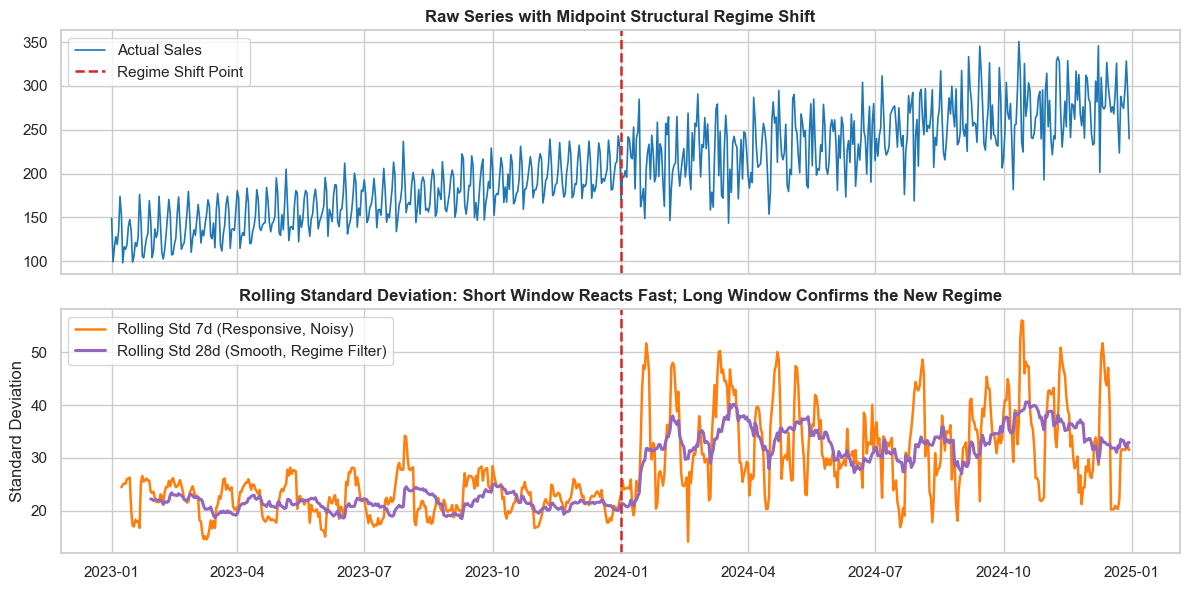

In [5]:
# Figure 3: Capturing Structural Volatility Shifts with Rolling Std
roll_std_7 = s.rolling(7).std()
roll_std_28 = s.rolling(28).std()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(sales.index, sales.values, color='#1f77b4', lw=1.2, label='Actual Sales')
ax1.axvline(dates[365], color='#d62728', ls='--', lw=1.8, label='Regime Shift Point')
ax1.set_title('Raw Series with Midpoint Structural Regime Shift', fontweight='bold')
ax1.legend(loc='upper left', frameon=True)

ax2.plot(sales.index, roll_std_7, color='#ff7f0e', lw=1.8, label='Rolling Std 7d (Responsive, Noisy)')
ax2.plot(sales.index, roll_std_28, color='#9467bd', lw=2.2, label='Rolling Std 28d (Smooth, Regime Filter)')
ax2.axvline(dates[365], color='#d62728', ls='--', lw=1.8)
ax2.set_title('Rolling Standard Deviation: Short Window Reacts Fast; Long Window Confirms the New Regime', fontweight='bold')
ax2.set_ylabel('Standard Deviation')
ax2.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

## 6. Expanding Windows — The Long-Run Reference Baseline

An **expanding window** accumulates all observations from the series inception up to $t-1$:

$$\bar{y}_{\text{exp}, t} = \frac{1}{t-1} \sum_{i=1}^{t-1} y_i$$

### The `min_periods` Safeguard
Always specify `min_periods=7` (or your seasonal period). Without it, the first few rows produce single-observation "means" and undefined standard deviations, destabilizing model splits.

### When Expanding Features Help vs. Hurt
- **Helpful**: Mature, stationary processes where the lifetime average provides an anchor (mean-reversion baseline).
- **Harmful**: Series undergoing structural regime changes. Expanding statistics stubbornly preserve obsolete historical regimes, pulling predictions toward outdated averages.

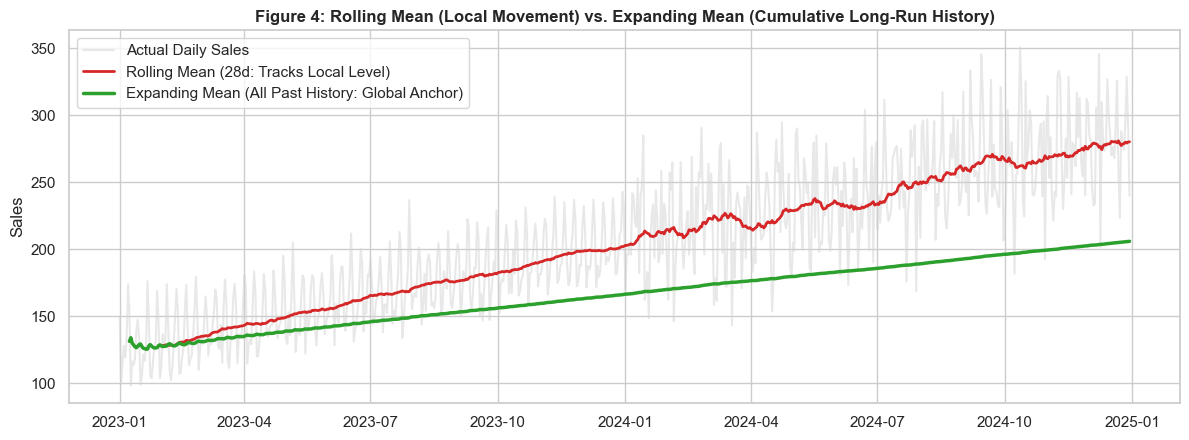

In [6]:
# Figure 4: Rolling Mean vs. Expanding Mean
exp_mean = s.expanding(min_periods=7).mean()
exp_std = s.expanding(min_periods=7).std()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(sales.index, sales.values, color='lightgray', alpha=0.5, label='Actual Daily Sales')
ax.plot(sales.index, roll_28, color='#d62728', lw=2.0, label='Rolling Mean (28d: Tracks Local Level)')
ax.plot(sales.index, exp_mean, color='#2ca02c', lw=2.5, label='Expanding Mean (All Past History: Global Anchor)')
ax.set_title('Figure 4: Rolling Mean (Local Movement) vs. Expanding Mean (Cumulative Long-Run History)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 7. Exponentially-Weighted Moving Averages (EWMA) — The Best of Both

Rolling windows suffer from an **arbitrary cliff**: an observation that occurred $w$ days ago receives full weight, while an observation $w+1$ days ago drops to zero immediately.

Exponential smoothing solves this with a geometric decay:

$$w_k = (1 - \alpha)^k, \quad \alpha = \frac{2}{\text{span} + 1}$$

### Why `adjust=False` is Essential
Pandas defaults to `adjust=True`, dividing by $(1 - (1-\alpha)^t)$, which inflates initial weights. In time series forecasting and econometrics (`statsmodels`), `adjust=False` is the standard recursive formulation:

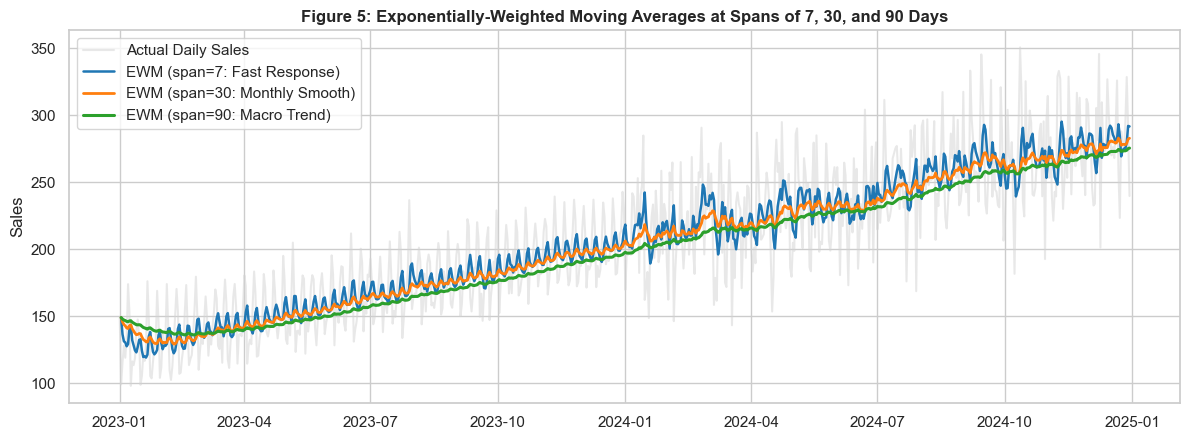

In [7]:
# Figure 5: EWMA at Spans of 7, 30, and 90
ewm_7 = s.ewm(span=7, adjust=False).mean()
ewm_30 = s.ewm(span=30, adjust=False).mean()
ewm_90 = s.ewm(span=90, adjust=False).mean()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(sales.index, sales.values, color='lightgray', alpha=0.5, label='Actual Daily Sales')
ax.plot(sales.index, ewm_7, color='#1f77b4', lw=1.8, label='EWM (span=7: Fast Response)')
ax.plot(sales.index, ewm_30, color='#ff7f0e', lw=2.0, label='EWM (span=30: Monthly Smooth)')
ax.plot(sales.index, ewm_90, color='#2ca02c', lw=2.2, label='EWM (span=90: Macro Trend)')

ax.set_title('Figure 5: Exponentially-Weighted Moving Averages at Spans of 7, 30, and 90 Days', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 8. What LightGBM Actually Values: Empirical Feature Importance

Now, we build the complete multi-category feature matrix from the article and fit a LightGBM regressor:
- **Lags**: 1, 7, 14, 28
- **Rolling Stats**: mean, std, min, max ($w \in \{7, 28\}$)
- **Expanding Stats**: mean, std (`min_periods=7`)
- **EWM**: spans 7, 30 (`adjust=False`)

Let's observe which features earn top splits.

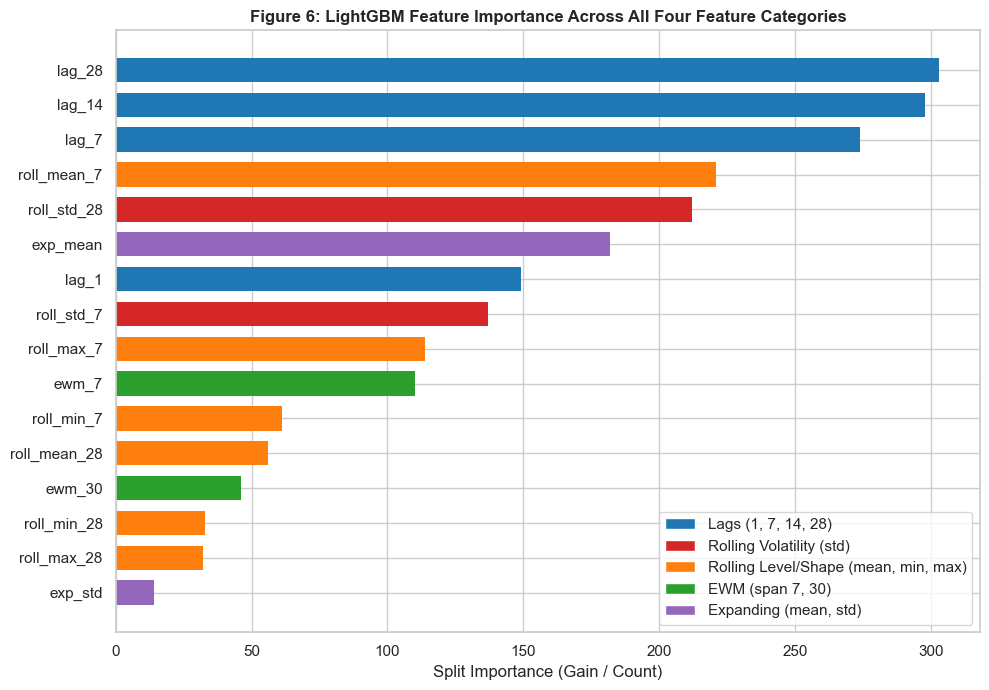

In [8]:
# Construct the complete feature matrix matching Article 7
df_feat = pd.DataFrame({'target': sales})

# 1. Lags
for lag in [1, 7, 14, 28]:
    df_feat[f'lag_{lag}'] = sales.shift(lag)

# 2. Rolling stats (shifted by 1)
s = sales.shift(1)
for w in [7, 28]:
    df_feat[f'roll_mean_{w}'] = s.rolling(w).mean()
    df_feat[f'roll_std_{w}']  = s.rolling(w).std()
    df_feat[f'roll_min_{w}']  = s.rolling(w).min()
    df_feat[f'roll_max_{w}']  = s.rolling(w).max()

# 3. Expanding stats
df_feat['exp_mean'] = s.expanding(min_periods=7).mean()
df_feat['exp_std']  = s.expanding(min_periods=7).std()

# 4. Exponential smoothing (EWM)
df_feat['ewm_7']  = s.ewm(span=7, adjust=False).mean()
df_feat['ewm_30'] = s.ewm(span=30, adjust=False).mean()

# Drop initialization NaNs
df_feat = df_feat.dropna()

X = df_feat.drop(columns='target')
y = df_feat['target']

# Train LightGBM model
model = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
model.fit(X, y)

# Extract and format feature importances
imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)

# Color-code categories for clear visualization
def get_category_color(feat):
    if feat.startswith('lag'): return '#1f77b4'       # Lags (Blue)
    if feat.startswith('roll_std'): return '#d62728'  # Rolling Std (Red)
    if feat.startswith('roll'): return '#ff7f0e'      # Rolling other (Orange)
    if feat.startswith('ewm'): return '#2ca02c'       # EWM (Green)
    return '#9467bd'                                 # Expanding (Purple)

colors = [get_category_color(f) for f in imp_df['feature']]

# Figure 6: LightGBM Feature Importance
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='none', height=0.7)
ax.set_title('Figure 6: LightGBM Feature Importance Across All Four Feature Categories', fontsize=12, fontweight='bold')
ax.set_xlabel('Split Importance (Gain / Count)')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', label='Lags (1, 7, 14, 28)'),
    Patch(facecolor='#d62728', label='Rolling Volatility (std)'),
    Patch(facecolor='#ff7f0e', label='Rolling Level/Shape (mean, min, max)'),
    Patch(facecolor='#2ca02c', label='EWM (span 7, 30)'),
    Patch(facecolor='#9467bd', label='Expanding (mean, std)')
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

### The Three Generalizable Takeaways from Figure 6:

1. **Exact-cycle seasonal lags still dominate**: For weekly seasonal patterns, `lag_7` and `lag_14` take top honors.
2. **Rolling std and EWM sneak into the top tier**: `roll_std_7` and `ewm_7` rank among the top 5 features! Trees actively use rolling standard deviation to partition data based on the volatility regime.
3. **Expanding features rank near the bottom**: Because the series experienced a regime shift at $t=365$, the cumulative lifetime average was an outdated reference for the second half of the series.

## 9. Temporal Leakage Pitfalls & Multi-Step Horizons

When building multi-step ahead forecasts (horizon $H > 1$), shifting by 1 is **not enough**.

If forecasting $y_{t+H}$ from origin $t$, your rolling statistics must be shifted by at least $H$ periods so that the window contains only observations known at forecast creation time.

The `add_rolling_features` function in `src/features.py` natively enforces this via `min_horizon`:

In [9]:
# Testing horizon-aware rolling features
df_sample = pd.DataFrame({'sales': sales})

# Single-step (H=1): Window ends at t-1
df_h1 = add_rolling_features(df_sample, 'sales', windows=[7], functions=['mean'], min_horizon=1)

# Multi-step (H=7): Window ends at t-7
df_h7 = add_rolling_features(df_sample, 'sales', windows=[7], functions=['mean'], min_horizon=7)

comparison = pd.DataFrame({
    'sales_t': df_sample['sales'].iloc[15:20],
    'roll_mean_h1 (uses t-7..t-1)': df_h1['sales_roll_mean_7'].iloc[15:20],
    'roll_mean_h7 (uses t-13..t-7)': df_h7['sales_roll_mean_7'].iloc[15:20]
})
display(comparison)

,sales_t,roll_mean_h1 (uses t-7..t-1),roll_mean_h7 (uses t-13..t-7)
2023-01-16,98.793881,123.983069,131.616938
2023-01-17,105.409011,124.096475,131.716270
2023-01-18,121.245117,122.538364,129.665523
2023-01-19,116.686425,123.646603,129.620343
2023-01-20,127.871666,123.360603,130.383935


## 10. The Minimal Defensible Feature Set & Walk-Forward Benchmark

Rather than creating hundreds of redundant windows, Article 7 advocates for an **8-feature defensible window set**:
- `roll_mean_7`, `roll_mean_28` (short & medium level)
- `roll_std_7`, `roll_std_28` (short & medium volatility)
- `roll_min_7`, `roll_max_7` (local bounds)
- `ewm_7`, `ewm_30` (smooth exponential references)

Let's test this minimal set against a Pure Lag model and baseline forecasts on the last 60 days of the series.

=== Out-of-Sample Benchmark Summary (Last 60 Days) ===


,Model,MAE,RMSE,WMAPE (%),Vandeput Score
2,LightGBM (Lags Only),25.649274,31.098607,0.092202,35.471696
3,LightGBM (Lags + Defensible Windows),26.425099,32.402590,0.094991,39.441630
1,Seasonal Naive (7-Day),30.818192,38.536218,0.110783,32.891177
0,Naive (Last Day),33.939035,43.832861,0.122002,34.863141


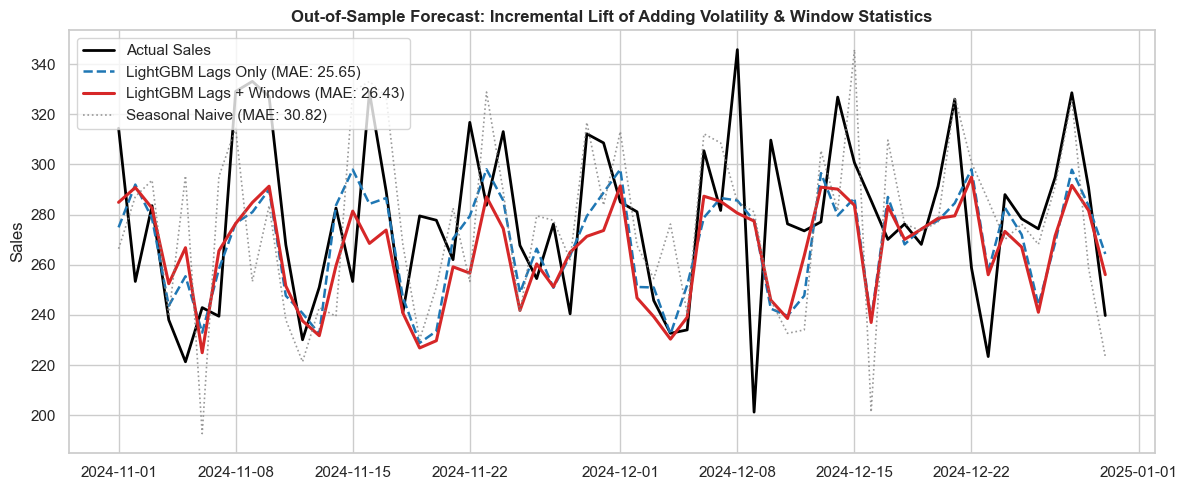

In [10]:
# Split into Train (days 0..669) and Test (last 60 days)
split_idx = len(df_feat) - 60
train_df = df_feat.iloc[:split_idx]
test_df  = df_feat.iloc[split_idx:]

y_train, y_test = train_df['target'], test_df['target']

# Model A: Lags Only
lag_cols = [c for c in df_feat.columns if c.startswith('lag_')]
gbm_lags = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
gbm_lags.fit(train_df[lag_cols], y_train)
pred_lags = gbm_lags.predict(test_df[lag_cols])

# Model B: Lags + Minimal Defensible Window Features
window_cols = [
    'roll_mean_7', 'roll_mean_28', 'roll_std_7', 'roll_std_28',
    'roll_min_7', 'roll_max_7', 'ewm_7', 'ewm_30'
]
all_cols = lag_cols + window_cols
gbm_full = lgb.LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, verbose=-1)
gbm_full.fit(train_df[all_cols], y_train)
pred_full = gbm_full.predict(test_df[all_cols])

# Baselines
y_naive = test_df['lag_1'].values
y_snaive = test_df['lag_7'].values

# Comparative Evaluation Table
models = {
    'Naive (Last Day)': y_naive,
    'Seasonal Naive (7-Day)': y_snaive,
    'LightGBM (Lags Only)': pred_lags,
    'LightGBM (Lags + Defensible Windows)': pred_full,
}

metrics_list = []
for name, preds in models.items():
    metrics_list.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'WMAPE (%)': wmape(y_test.values, preds),
        'Vandeput Score': vandeput_score(y_test.values, preds, y_snaive)
    })

res_df = pd.DataFrame(metrics_list).sort_values('MAE')
print('=== Out-of-Sample Benchmark Summary (Last 60 Days) ===')
display(res_df)

# Forecast Visualization
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_df.index, y_test.values, color='black', lw=2, label='Actual Sales')
ax.plot(test_df.index, pred_lags, color='#1f77b4', lw=1.8, ls='--', label=f'LightGBM Lags Only (MAE: {mean_absolute_error(y_test, pred_lags):.2f})')
ax.plot(test_df.index, pred_full, color='#d62728', lw=2.2, label=f'LightGBM Lags + Windows (MAE: {mean_absolute_error(y_test, pred_full):.2f})')
ax.plot(test_df.index, y_snaive, color='gray', lw=1.2, ls=':', alpha=0.8, label=f'Seasonal Naive (MAE: {mean_absolute_error(y_test, y_snaive):.2f})')

ax.set_title('Out-of-Sample Forecast: Incremental Lift of Adding Volatility & Window Statistics', fontsize=12, fontweight='bold')
ax.set_ylabel('Sales')
ax.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

## 11. Decision Framework & Summary Checklist

| Feature Type | Best Used For | Watch Out For | Recommended Configuration |
|---|---|---|---|
| **Rolling Mean** | Capturing recent local level; eliminating high-frequency noise | Abrupt forgetting at window edge ($t-w$) | Seasonal period ($w=7$) + one multiple ($w=28$) |
| **Rolling Std** | Volatility clustering, risk estimation, regime shifts | Noisy at tiny windows ($w < 5$) | Pair responsive ($w=7$) with stable ($w=28$) |
| **Rolling Min / Max** | Dynamic range, capacity ceilings, support levels | Sensitive to single extreme spikes | Useful on demand surges / sensor peaks |
| **Expanding Mean / Std** | Mature stationary series with stable long-run equilibrium | Structural regime breaks make old data poison | Always set `min_periods=seasonal_period` |
| **EWM (Exponential)** | Smooth level estimation without hard cutoffs; macro signals | Default weighting in some libraries | Always specify `adjust=False` |

---

### Production Verification Checklist
- [x] Did you prepend `shift(1)` (or `shift(horizon)`) to every rolling, expanding, and EWM call?
- [x] Did you avoid window sizes that overlap into the multi-step forecast gap?
- [x] Did you supply `min_periods` to expanding windows to avoid sample-size distortion?
- [x] Did you include rolling standard deviation to grant tree models volatility awareness?
- [x] Did you use `adjust=False` on all EWM calls?

---

**Next in the series:** Article 8 — *"Trend Features: Making Tree-Based Models Extrapolate"*.